# 1. IMPORT LIBRARIES

#### Import libraries for data handling, NLP preprocessing, feature extraction and modelling

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import nltk
from nltk.corpus import stopwords
from scipy.sparse import hstack
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLP resources

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuauvie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuauvie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joshuauvie/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 2. LOAD AND PREPARE DATA

### Load training datasets

In [3]:
train_bodies = pd.read_csv('train_bodies.csv')
train_bodies.head()

,Body ID,articleBody
0,0,A small meteorite crashed into a wooded area i...
1,4,Last week we hinted at what was to come as Ebo...
2,5,(NEWSER) – Wonder how long a Quarter Pounder w...
3,6,"Posting photos of a gun-toting child online, I..."
4,7,At least 25 suspected Boko Haram insurgents we...


In [4]:
train_bodies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1683 entries, 0 to 1682
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      1683 non-null   int64 
 1   articleBody  1683 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB


In [5]:
train_bodies['Body ID'].value_counts()

Body ID
0       1
1661    1
1702    1
1700    1
1699    1
       ..
834     1
833     1
832     1
831     1
2532    1
Name: count, Length: 1683, dtype: int64

In [6]:
train_stances = pd.read_csv('train_stances.csv')
train_stances.head()

,Headline,Body ID,Stance
0,Police find mass graves with at least '15 bodi...,712,unrelated
1,Hundreds of Palestinians flee floods in Gaza a...,158,agree
2,"Christian Bale passes on role of Steve Jobs, a...",137,unrelated
3,HBO and Apple in Talks for $15/Month Apple TV ...,1034,unrelated
4,Spider burrowed through tourist's stomach and ...,1923,disagree


In [7]:
train_stances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49972 entries, 0 to 49971
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Headline  49972 non-null  object
 1   Body ID   49972 non-null  int64 
 2   Stance    49972 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [8]:
train_stances['Body ID'].value_counts()

Body ID
1921    187
1948    175
40      172
524     171
1549    166
       ... 
16        1
65        1
114       1
24        1
1066      1
Name: count, Length: 1683, dtype: int64

### Merge datasets on Body ID to create full training dataset


In [9]:
train_df = pd.merge(train_bodies, train_stances, on='Body ID')
train_df.head()

,Body ID,articleBody,Headline,Stance
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49972 entries, 0 to 49971
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      49972 non-null  int64 
 1   articleBody  49972 non-null  object
 2   Headline     49972 non-null  object
 3   Stance       49972 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


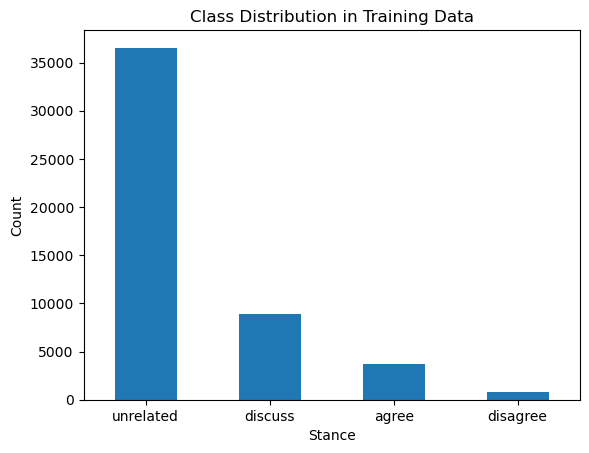

In [11]:
# Plot class distribution
train_df['Stance'].value_counts().plot(kind='bar')

plt.title("Class Distribution in Training Data")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

### Load validation datasets


In [12]:
val_bodies = pd.read_csv('competition_test_bodies.csv')
val_bodies.head()

,Body ID,articleBody
0,1,Al-Sisi has denied Israeli reports stating tha...
1,2,A bereaved Afghan mother took revenge on the T...
2,3,CNBC is reporting Tesla has chosen Nevada as t...
3,12,A 4-inch version of the iPhone 6 is said to be...
4,19,GR editor’s Note\n\nThere are no reports in th...


In [13]:
val_bodies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      904 non-null    int64 
 1   articleBody  904 non-null    object
dtypes: int64(1), object(1)
memory usage: 14.3+ KB


In [14]:
val_stances_un = pd.read_csv('competition_test_stances_unlabeled.csv')
val_stances_un.head()

,Headline,Body ID
0,Ferguson riots: Pregnant woman loses eye after...,2008
1,Crazy Conservatives Are Sure a Gitmo Detainee ...,1550
2,A Russian Guy Says His Justin Bieber Ringtone ...,2
3,"Zombie Cat: Buried Kitty Believed Dead, Meows ...",1793
4,Argentina's President Adopts Boy to End Werewo...,37


In [15]:
val_stances_un.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25413 entries, 0 to 25412
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Headline  25413 non-null  object
 1   Body ID   25413 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 397.2+ KB


In [16]:
val_stances = pd.read_csv('competition_test_stances.csv')
val_stances.head()

,Headline,Body ID,Stance
0,Ferguson riots: Pregnant woman loses eye after...,2008,unrelated
1,Crazy Conservatives Are Sure a Gitmo Detainee ...,1550,unrelated
2,A Russian Guy Says His Justin Bieber Ringtone ...,2,unrelated
3,"Zombie Cat: Buried Kitty Believed Dead, Meows ...",1793,unrelated
4,Argentina's President Adopts Boy to End Werewo...,37,unrelated


In [17]:
val_stances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25413 entries, 0 to 25412
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Headline  25413 non-null  object
 1   Body ID   25413 non-null  int64 
 2   Stance    25413 non-null  object
dtypes: int64(1), object(2)
memory usage: 595.7+ KB


### Merge validation data


In [18]:
val_df = pd.merge(val_bodies, val_stances, on='Body ID', how='inner')
val_df.head()

,Body ID,articleBody,Headline,Stance
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...,unrelated
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...,agree
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...,unrelated
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...,unrelated
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...,unrelated


### Load test datasets (unlabelled)


In [19]:
test_bodies = pd.read_csv('test_bodies.csv')
test_bodies.head()

,Body ID,articleBody
0,1,Al-Sisi has denied Israeli reports stating tha...
1,2,A bereaved Afghan mother took revenge on the T...
2,3,CNBC is reporting Tesla has chosen Nevada as t...
3,12,A 4-inch version of the iPhone 6 is said to be...
4,19,GR editor’s Note\n\nThere are no reports in th...


In [20]:
test_bodies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      904 non-null    int64 
 1   articleBody  904 non-null    object
dtypes: int64(1), object(1)
memory usage: 14.3+ KB


In [21]:
test_stances = pd.read_csv('test_stances_unlabeled.csv')
test_stances.head()

,Headline,Body ID
0,Ferguson riots: Pregnant woman loses eye after...,2008
1,Crazy Conservatives Are Sure a Gitmo Detainee ...,1550
2,A Russian Guy Says His Justin Bieber Ringtone ...,2
3,"Zombie Cat: Buried Kitty Believed Dead, Meows ...",1793
4,Argentina's President Adopts Boy to End Werewo...,37


In [22]:
test_stances.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25413 entries, 0 to 25412
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Headline  25413 non-null  object
 1   Body ID   25413 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 397.2+ KB


### Merge test data


In [23]:
test_df = pd.merge(test_bodies, test_stances, on='Body ID', how='inner')
test_df.head()

,Body ID,articleBody,Headline
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...


In [24]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25413 entries, 0 to 25412
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      25413 non-null  int64 
 1   articleBody  25413 non-null  object
 2   Headline     25413 non-null  object
dtypes: int64(1), object(2)
memory usage: 595.7+ KB


# 3. TEXT PREPROCESSING

### Initialize stopwords and lemmatizer


In [25]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """
    Clean and preprocess text:
    - Lowercase conversion
    - Tokenisation
    - Remove non-alphanumeric tokens
    - Remove stopwords
    - Lemmatization
    """
    text = str(text).lower()
    tokens = word_tokenize(text)

    # Keep only alphanumeric words
    tokens = [word for word in tokens if word.isalnum()]

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize words
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [26]:
def prepare_dataset(df):

    """
    Apply preprocessing to headline and body,
    then combine into a single text feature.
    """
    
    df['Headline_clean'] = df['Headline'].apply(preprocess)
    df['Body_clean'] = df['articleBody'].apply(preprocess)
    
    df['text'] = df['Headline_clean'] + " " + df['Body_clean']
    
    return df

### Apply preprocessing

In [27]:
train_df = prepare_dataset(train_df)

In [28]:
train_df.shape

(49972, 7)

In [29]:
train_df[['Headline','Headline_clean']].head()

,Headline,Headline_clean
0,"Soldier shot, Parliament locked down after gun...",soldier shot parliament locked gunfire erupts ...
1,Tourist dubbed ‘Spider Man’ after spider burro...,tourist dubbed spider man spider burrow skin day
2,Luke Somers 'killed in failed rescue attempt i...,luke somers failed rescue attempt yemen
3,BREAKING: Soldier shot at War Memorial in Ottawa,breaking soldier shot war memorial ottawa
4,Giant 8ft 9in catfish weighing 19 stone caught...,giant 8ft 9in catfish weighing 19 stone caught...


In [30]:
train_df.head()

,Body ID,articleBody,Headline,Stance,Headline_clean,Body_clean,text
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated,soldier shot parliament locked gunfire erupts ...,small meteorite crashed wooded area nicaragua ...,soldier shot parliament locked gunfire erupts ...
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated,tourist dubbed spider man spider burrow skin day,small meteorite crashed wooded area nicaragua ...,tourist dubbed spider man spider burrow skin d...
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated,luke somers failed rescue attempt yemen,small meteorite crashed wooded area nicaragua ...,luke somers failed rescue attempt yemen small ...
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated,breaking soldier shot war memorial ottawa,small meteorite crashed wooded area nicaragua ...,breaking soldier shot war memorial ottawa smal...
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated,giant 8ft 9in catfish weighing 19 stone caught...,small meteorite crashed wooded area nicaragua ...,giant 8ft 9in catfish weighing 19 stone caught...


In [31]:
val_df = prepare_dataset(val_df)

In [32]:
val_df.shape

(25413, 7)

In [33]:
val_df.head()

,Body ID,articleBody,Headline,Stance,Headline_clean,Body_clean,text
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...,unrelated,apple installing safe protect gold watch edition,denied israeli report stating offered extend g...,apple installing safe protect gold watch editi...
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...,agree,denies claim give sinai land palestinian,denied israeli report stating offered extend g...,denies claim give sinai land palestinian denie...
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...,unrelated,apple keep gold watch edition special safe,denied israeli report stating offered extend g...,apple keep gold watch edition special safe den...
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...,unrelated,apple store keep gold edition apple watch cust...,denied israeli report stating offered extend g...,apple store keep gold edition apple watch cust...
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...,unrelated,south korean woman hair robot vacuum cleaner s...,denied israeli report stating offered extend g...,south korean woman hair robot vacuum cleaner s...


# 4. BASELINE MODEL (TF-IDF + NAIVE BAYES)

### Convert text into TF-IDF features (unigram representation)


In [34]:
vectorizer = TfidfVectorizer(
    max_features=10000
)

In [35]:
X_train = vectorizer.fit_transform(train_df["text"])
y_train = train_df['Stance']

In [36]:
X_val = vectorizer.transform(val_df["text"])
y_val = val_df['Stance']

### Train baseline model


In [37]:
model_1 = MultinomialNB()

In [38]:
model_1.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Make predictions


In [39]:
baseline_predictions = model_1.predict(X_val)

### Store predictions


In [40]:
val_df["Baseline_Predicted"] = baseline_predictions

# 5. BASELINE EVALUATION

### Identify misclassified examples


In [41]:
baseline_errors = val_df[val_df["Stance"] != val_df["Baseline_Predicted"]]

baseline_errors[["Headline","Stance","Baseline_Predicted"]].head(6)

,Headline,Stance,Baseline_Predicted
1,El-Sisi denies claims he'll give Sinai land to...,agree,unrelated
34,Afghan Mother Kills 25 Taliban Fighters In Sev...,agree,unrelated
107,REPORT: Tesla Chooses Nevada For Site Of Its M...,discuss,unrelated
201,4-inch iPhone 6 reported to be in development,discuss,unrelated
261,How a Reddit user convinced Tim Cook to change...,agree,unrelated
269,Charles Manson's fiancee used him for his ... ...,discuss,unrelated


### Display sample errors


In [42]:
print(baseline_errors[["Headline","Stance","Baseline_Predicted"]].head(6))

                                              Headline   Stance  \
1    El-Sisi denies claims he'll give Sinai land to...    agree   
34   Afghan Mother Kills 25 Taliban Fighters In Sev...    agree   
107  REPORT: Tesla Chooses Nevada For Site Of Its M...  discuss   
201      4-inch iPhone 6 reported to be in development  discuss   
261  How a Reddit user convinced Tim Cook to change...    agree   
269  Charles Manson's fiancee used him for his ... ...  discuss   

    Baseline_Predicted  
1            unrelated  
34           unrelated  
107          unrelated  
201          unrelated  
261          unrelated  
269          unrelated  


### Evaluate model performance


In [43]:
result = {}

In [44]:
result['Baseline Model'] = {
    "Accuracy": accuracy_score(y_val, baseline_predictions),
    "Precision": precision_score(y_val, baseline_predictions, average='weighted'),
    "Recall": recall_score(y_val, baseline_predictions, average='weighted'),
    "F1 Score": f1_score(y_val, baseline_predictions, average='weighted')
    }

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
result

{'Baseline Model': {'Accuracy': 0.6798095462952033,
  'Precision': 0.5807194016254352,
  'Recall': 0.6798095462952033,
  'F1 Score': 0.6228473765218818}}

### Print classification report


In [46]:
print(classification_report(y_val, baseline_predictions))

              precision    recall  f1-score   support

       agree       0.00      0.00      0.00      1903
    disagree       0.00      0.00      0.00       697
     discuss       0.30      0.20      0.24      4464
   unrelated       0.73      0.89      0.80     18349

    accuracy                           0.68     25413
   macro avg       0.26      0.27      0.26     25413
weighted avg       0.58      0.68      0.62     25413



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


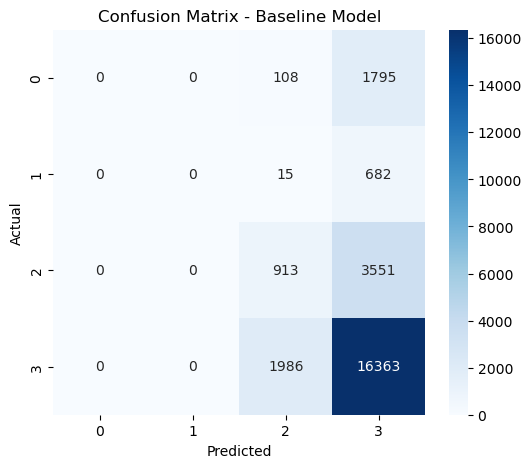

In [47]:
cm = confusion_matrix(y_val, baseline_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 6. FEATURE ENGINEERING (IMPROVED MODEL)

### Add structural features: headline and body length


In [48]:
train_df["headline_length"] = train_df["Headline"].apply(lambda x: len(str(x).split()))
train_df["body_length"] = train_df["articleBody"].apply(lambda x: len(str(x).split()))

In [49]:
val_df["headline_length"] = val_df["Headline"].apply(lambda x: len(str(x).split()))
val_df["body_length"] = val_df["articleBody"].apply(lambda x: len(str(x).split()))

### Define negation words


In [50]:
negation_words = [
    "not", "no", "never", "none", "nothing",
    "neither", "nor", "cannot", "n't"
]

In [51]:
def count_negations(text):

    """
    Count number of negation words in text.
    Helps capture polarity shifts.
    """

    tokens = word_tokenize(str(text).lower())
    count = sum(1 for word in tokens if word in negation_words)

    return count

### Apply negation feature


In [52]:
train_df["negation_count"] = train_df["text"].apply(count_negations)

In [53]:
val_df["negation_count"] = val_df["text"].apply(count_negations)

# 7. TF-IDF WITH N-GRAMS

### Use both unigrams and bigrams for improved representation


In [54]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

### Combine TF-IDF with additional engineered features


In [55]:
X_train_tfidf = vectorizer.fit_transform(train_df["text"])

extra_train = train_df[
    ["negation_count", "headline_length", "body_length"]
].values

X_train = hstack([X_train_tfidf, extra_train])
y_train = train_df['Stance']

In [56]:
y_train.value_counts()

Stance
unrelated    36545
discuss       8909
agree         3678
disagree       840
Name: count, dtype: int64

In [57]:
X_val_tfidf = vectorizer.transform(val_df["text"])

extra_val = val_df[
    ["negation_count", "headline_length", "body_length"]
].values

X_val = hstack([X_val_tfidf, extra_val])
y_val = val_df['Stance']

# 8. IMPROVED MODEL


### Train improved model using additional features


In [58]:
model_2 = MultinomialNB()

In [59]:
model_2.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Predictions


In [60]:
improved_predictions = model_2.predict(X_val)

In [61]:
val_df["Improved_Predicted"] = improved_predictions

# 9. IMPROVED MODEL EVALUATION


### Identify errors


In [62]:
improved_errors = val_df[val_df["Stance"] != val_df["Improved_Predicted"]]

improved_errors[["Headline","Stance","Improved_Predicted"]].head(6)

,Headline,Stance,Improved_Predicted
1,El-Sisi denies claims he'll give Sinai land to...,agree,unrelated
34,Afghan Mother Kills 25 Taliban Fighters In Sev...,agree,unrelated
107,REPORT: Tesla Chooses Nevada For Site Of Its M...,discuss,unrelated
201,4-inch iPhone 6 reported to be in development,discuss,unrelated
261,How a Reddit user convinced Tim Cook to change...,agree,unrelated
269,Charles Manson's fiancee used him for his ... ...,discuss,unrelated


In [63]:
print(improved_errors[["Headline","Stance","Improved_Predicted"]].head(6))

                                              Headline   Stance  \
1    El-Sisi denies claims he'll give Sinai land to...    agree   
34   Afghan Mother Kills 25 Taliban Fighters In Sev...    agree   
107  REPORT: Tesla Chooses Nevada For Site Of Its M...  discuss   
201      4-inch iPhone 6 reported to be in development  discuss   
261  How a Reddit user convinced Tim Cook to change...    agree   
269  Charles Manson's fiancee used him for his ... ...  discuss   

    Improved_Predicted  
1            unrelated  
34           unrelated  
107          unrelated  
201          unrelated  
261          unrelated  
269          unrelated  


### Store results


In [64]:
result['Improved Model'] = {
    "Accuracy": accuracy_score(y_val, improved_predictions),
    "Precision": precision_score(y_val, improved_predictions, average='weighted'),
    "Recall": recall_score(y_val, improved_predictions, average='weighted'),
    "F1 Score": f1_score(y_val, improved_predictions, average='weighted')
    }

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


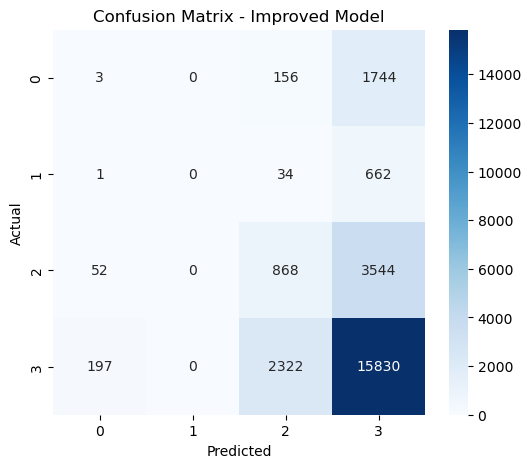

In [65]:
cm = confusion_matrix(y_val, improved_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Improved Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Compare models


In [66]:
comparison_df = pd.DataFrame(result).T.round(4)
comparison_df

,Accuracy,Precision,Recall,F1 Score
Baseline Model,0.6798,0.5807,0.6798,0.6228
Improved Model,0.6572,0.5708,0.6572,0.6087


In [67]:
print(classification_report(y_val, improved_predictions))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       agree       0.01      0.00      0.00      1903
    disagree       0.00      0.00      0.00       697
     discuss       0.26      0.19      0.22      4464
   unrelated       0.73      0.86      0.79     18349

    accuracy                           0.66     25413
   macro avg       0.25      0.26      0.25     25413
weighted avg       0.57      0.66      0.61     25413



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


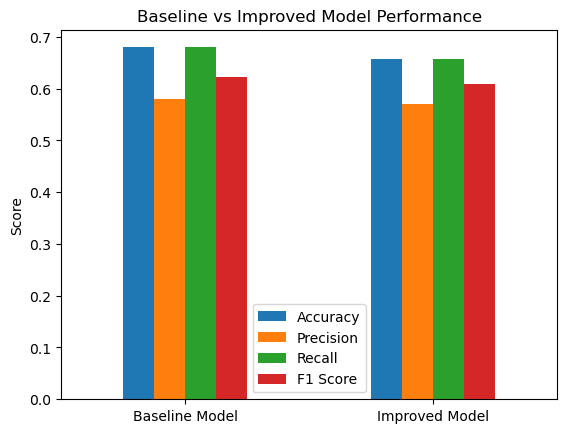

In [68]:
comparison_df.plot(kind='bar')

plt.title("Baseline vs Improved Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# 10. TEST SET PREDICTION


### Prepare test data


In [69]:
test_df = prepare_dataset(test_df)

In [70]:
test_df.shape

(25413, 6)

In [71]:
test_df.head()

,Body ID,articleBody,Headline,Headline_clean,Body_clean,text
0,1,Al-Sisi has denied Israeli reports stating tha...,Apple installing safes in-store to protect gol...,apple installing safe protect gold watch edition,denied israeli report stating offered extend g...,apple installing safe protect gold watch editi...
1,1,Al-Sisi has denied Israeli reports stating tha...,El-Sisi denies claims he'll give Sinai land to...,denies claim give sinai land palestinian,denied israeli report stating offered extend g...,denies claim give sinai land palestinian denie...
2,1,Al-Sisi has denied Israeli reports stating tha...,Apple to keep gold Watch Editions in special i...,apple keep gold watch edition special safe,denied israeli report stating offered extend g...,apple keep gold watch edition special safe den...
3,1,Al-Sisi has denied Israeli reports stating tha...,Apple Stores to Keep Gold “Edition” Apple Watc...,apple store keep gold edition apple watch cust...,denied israeli report stating offered extend g...,apple store keep gold edition apple watch cust...
4,1,Al-Sisi has denied Israeli reports stating tha...,South Korean woman's hair 'eaten' by robot vac...,south korean woman hair robot vacuum cleaner s...,denied israeli report stating offered extend g...,south korean woman hair robot vacuum cleaner s...


### Apply same feature engineering


In [72]:
test_df["negation_count"] = test_df["text"].apply(count_negations)

In [73]:
test_df["headline_length"] = test_df["Headline"].apply(lambda x: len(str(x).split()))
test_df["body_length"] = test_df["articleBody"].apply(lambda x: len(str(x).split()))

### Transform features


In [74]:
X_test_tfidf = vectorizer.transform(test_df['text'])

extra_test = test_df[
    ["negation_count", "headline_length", "body_length"]
].values

X_test = hstack([X_test_tfidf, extra_test])

### Predict


In [75]:
test_predictions = model_2.predict(X_test)

### Store predictions


In [76]:
test_df['Predicted_Stance'] = test_predictions

### View results


In [77]:
test_df[['Headline','Predicted_Stance']].head()

,Headline,Predicted_Stance
0,Apple installing safes in-store to protect gol...,unrelated
1,El-Sisi denies claims he'll give Sinai land to...,unrelated
2,Apple to keep gold Watch Editions in special i...,unrelated
3,Apple Stores to Keep Gold “Edition” Apple Watc...,unrelated
4,South Korean woman's hair 'eaten' by robot vac...,unrelated
